# CDS_v2

1. Here, we'll take featureCounts data and its transformations:
    - log2 transformed data
    - VST
    - VST-quantile normalised data
2. Compare distributions of values
3. Pass each through CD vector generation
4. Overlay onto graph_cds

5. Take the same random CD vector data and statin data to compare each type

6. Set up un-learning and learning GIN architecture
7. Run multiple embeddings
    - Compare unique IDs in top 10 closest IDs
    - Compare across datasets
    - If n seeds are run, how many different unique IDs are returned?
    - Is there an n seeds where no new unique IDs are added?

# Packages

In [190]:
import itertools
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import pyarrow.parquet as pq
import random
import seaborn as sns
from scipy.stats.mstats import zscore
from sklearn.decomposition import PCA
from tqdm import tqdm as tqdm

# GIN
from sklearn.metrics.pairwise import cosine_similarity
import torch
from torch.nn import Sequential, Identity, Module, Linear, ReLU
import torch.nn.functional as F
from torch_geometric.data import DataLoader
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.utils import from_networkx

# uMAP
import umap.umap_ as umap

# Directories

In [152]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'

OUTPUT = 'D:/DDesktop/_work/data/canada/output/'
TABULAR = OUTPUT + 'tabular/'
LOG = OUTPUT + 'transform_log/'
CPM = OUTPUT + 'transform_logcpm/'
VST = OUTPUT + 'transform_vst/'
QNT = OUTPUT + 'transform_quantile/'
CDV = OUTPUT + 'cd_vectors/'
CONTEXT = OUTPUT + 'context_graphs/'

# Functions

In [92]:
def chdir(data, sampleclass, genes, gamma=1., sort=True, calculate_sig=False, nnull=10, sig_only=False, norm_vector=True):
	"""
	Calculate the characteristic direction for a gene expression dataset
	
	Input:
		data: numpy.array, is the data matrix of gene expression where rows correspond to genes and columns correspond to samples
		sampleclass: list or numpy.array, labels of the samples, it has to be consist of 0, 1 and 2, with 0 being columns to be excluded, 1 being control and 2 being perturbation
				example: sampleclass = [1,1,1,2,2,2]
		genes: list or numpy.array, row labels for genes 
		gamma: float, regulaized term. A parameter that smooths the covariance matrix and reduces potential noise in the dataset
		sort: bool, whether to sort the output by the absolute value of chdir
		calculate_sig: bool, whether to calculate the significance of characteristic directions
		nnull: int, number of null characteristic directions to calculate for significance
		sig_only: bool, whether to return only significant genes; active only when calculate_sig is True
		norm_vector: bool, whether to return a characteristic direction vector normalized to unit vector
	Output:
		A list of tuples sorted by the absolute value in descending order characteristic directions of genes.
			If calculate_sig is set to True, each tuple contains a third element which is the ratio of characteristic directions to null ChDir
	"""
	
	## check input
	data.astype(float)
	sampleclass = np.array(list(map(int, sampleclass)))
	# masks
	m_non0 = sampleclass != 0
	m1 = sampleclass[m_non0] == 1
	m2 = sampleclass[m_non0] == 2

	if type(gamma) not in [float, int]:
		raise ValueError("gamma has to be a numeric number")
	if set(sampleclass) != set([1,2]) and set(sampleclass) != set([0,1,2]):
		raise ValueError("sampleclass has to be a list whose elements are in only 0, 1 or 2")
	# if m1.sum()<2 or m2.sum()<2:
	# 	raise ValueError("Too few samples to calculate characteristic directions")
	if len(genes) != data.shape[0]:
		raise ValueError("Number of genes does not match the demension of the expression matrix")

	## normalize data
	data = data[:, m_non0]
	data = zscore(data) # standardize for each genes across samples

	## start to compute
	n1 = m1.sum() # number of controls
	n2 = m2.sum() # number of experiments

	## the difference between experiment mean vector and control mean vector.
	meanvec = data[:,m2].mean(axis=1) - data[:,m1].mean(axis=1) 

	## initialize the pca object
	pca = PCA(n_components=None)
	pca.fit(data.T)

	## compute the number of PCs to keep
	cumsum = pca.explained_variance_ratio_ # explained variance of each PC
	keepPC = len(cumsum[cumsum > 0.001]) # number of PCs to keep

	v = pca.components_[0:keepPC].T # rotated data 
	r = pca.transform(data.T)[:,0:keepPC] # transformed data

	dd = ( np.dot(r[m1].T,r[m1]) + np.dot(r[m2].T,r[m2]) ) / float(n1+n2-2) # covariance
	sigma = np.mean(np.diag(dd)) # the scalar covariance

	shrunkMats = np.linalg.inv(gamma*dd + sigma*(1-gamma)*np.eye(keepPC))

	b = np.dot(v, np.dot(np.dot(v.T, meanvec), shrunkMats))

	if norm_vector:
		b /= np.linalg.norm(b) # normalize b to unit vector

	grouped = zip([abs(item) for item in b],b,genes)
	if sort:
		grouped = sorted(grouped,key=lambda x: x[0], reverse=True)


	if not calculate_sig: # return sorted b and genes.
		res = [(item[1],item[2]) for item in grouped]
		return res
	else: # generate a null distribution of chdirs
		nu = n1 + n2 - 2
		y1 = np.random.multivariate_normal(np.zeros(keepPC), dd, nnull).T * np.sqrt(nu / chi2.rvs(nu,size=nnull))
		y2 = np.random.multivariate_normal(np.zeros(keepPC), dd, nnull).T * np.sqrt(nu / chi2.rvs(nu,size=nnull))
		y = y2 - y1 ## y is the null of v

		nullchdirs = []
		for col in y.T:
			bn = np.dot(np.dot(np.dot(v,shrunkMats), v.T), np.dot(col,v.T))
			bn /= np.linalg.norm(bn)
			bn = bn ** 2
			bn.sort()
			bn = bn[::-1] ## sort in decending order
			nullchdirs.append(bn)

		nullchdirs = np.array(nullchdirs).T
		nullchdirs = nullchdirs.mean(axis=1)
		b_s = b ** 2 
		b_s.sort()
		b_s = b_s[::-1] # sorted b in decending order
		relerr = b_s / nullchdirs ## relative error
		# ratio_to_null
		ratios = np.cumsum(relerr)/np.sum(relerr)- np.linspace(1./len(meanvec),1,len(meanvec))
		res = [(item[1],item[2], ratio) for item, ratio in zip(grouped, ratios)] 
		print('Number of significant genes: %s'%(np.argmax(ratios)+1))
		if sig_only:
			return res[0:np.argmax(ratios)+1]
		else:
			return res

def file_to_list(path):
    '''
    Converts a .txt file to a list
    '''

    with open(f'{path}', 'r', encoding = 'utf-8') as f:
        list_file = [line.strip() for line in f]
    
    return list_file

def list_to_file(path, data):
      '''
      Saves a list or set to a .txt file with no header.
      '''

      with open(path, 'w') as f:
            for item in sorted(data):
                  f.write(f'{item}\n')

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()

# 1. Data Normalisation

Here I'll take tabular featureCounts output and transform in various ways:    
- Log2
- LogCPM

VST and VST + quantile normalised files are already present in OUTPUT

In [5]:
# Load graph_cds
graph_cds = pickle_load(INPUT + 'graph_cds.pkl')
# Get nodelist
list_lm = list(graph_cds.nodes)

In [ ]:
# Define timepoint list
list_timepoint = ['6h', '24h']

## 1.1 Log2 normalisation

In [30]:
# Iterate through timepoints
for timepoint in tqdm(list_timepoint, desc = f'Applying log2 normalisation to featureCounts data', total = len(list_timepoint)):
    # Generate file list
    list_files = [file for file in os.listdir(TABULAR) if timepoint in file and '_CON_' not in file and '96h_' not in file]
    
    # Initialise dataframe
    df_normal = pd.DataFrame()

    # Iterate through file list
    for file in list_files:
        # Get file name
        filename = file.split('.')[0]
        # Load data
        df_file = pd.read_csv(TABULAR + file, sep = '\t')
        # Rename columns
        df_file.rename(columns = {'count' : filename}, inplace = True)

        # Merge
        if df_normal.empty:
            df_normal = df_file
        else:
            df_normal = pd.merge(df_normal, df_file, how = 'left', on = 'Geneid')

    # Format
    df_normal.rename(columns = {'Geneid' : 'gene_symbol'}, inplace = True)
    df_normal.set_index('gene_symbol', inplace = True)
    
    # Iterate through columns
    for column in df_normal.columns:
        # Apply log2 transformation
        df_normal[column] = np.log2(df_normal[column] + 1)
    
    # Filter landmark genes
    df_normal = df_normal[df_normal.index.isin(list_lm)]
    # Save data
    df_normal.to_csv(LOG + f'{timepoint}_log2_landmark.csv', index = True)

# Show data
df_normal.head()

Applying log2 normalisation to featureCounts data: 100%|██████████| 2/2 [00:01<00:00,  1.31it/s]


,24h_colo_halo_1,24h_colo_halo_2,24h_colo_halo_3,24h_colo_nita_1,24h_colo_nita_2,24h_colo_nita_3,24h_colo_paro_1,24h_colo_paro_2,24h_colo_paro_3,24h_inf_halo_1,...,24h_inf_nita_3,24h_inf_paro_1,24h_inf_paro_2,24h_inf_paro_3,24h_inf_positive_1,24h_inf_positive_2,24h_inf_positive_3,24h_inf_vehicle_1,24h_inf_vehicle_2,24h_inf_vehicle_3
gene_symbol,,,,,,,,,,,,,,,,,,,,,
DFFB,3.000000,2.807355,4.247928,6.768184,6.169925,6.658211,6.768184,6.507795,7.033423,3.700440,...,6.614710,6.918863,6.303781,6.930737,6.409391,6.794416,6.807355,6.754888,7.055282,7.199672
ICMT,9.396605,9.544964,9.501837,12.093087,11.496354,12.125736,11.900489,11.911766,12.377482,9.479780,...,11.584493,11.998238,11.625709,12.109831,11.702606,10.915132,12.036174,11.969387,12.289154,12.287424
KLHL21,12.087463,12.059006,11.903505,10.824959,10.512740,10.740624,10.342075,10.548822,10.939579,12.276124,...,10.096715,10.412570,10.207014,10.733015,10.371777,10.484823,10.721954,10.526499,11.032046,10.897089
CLSTN1,11.761551,11.725792,11.843529,12.584728,12.009479,12.519145,12.211888,12.350387,12.686938,11.970106,...,12.066426,12.402479,12.113091,12.444238,12.218260,12.676618,12.594791,12.523072,12.842154,12.757390
DFFA,9.995767,9.629357,10.056638,11.683433,11.178665,11.627534,11.672425,11.317413,11.802112,9.800900,...,11.132500,11.625709,11.673309,11.607330,11.229420,11.346514,11.731319,11.459432,11.743993,11.685625


## 1.2 LogCPM normalisation

In [31]:
# Iterate through timepoints
for timepoint in tqdm(list_timepoint, desc = f'Applying logCPM normalisation to featureCounts data', total = len(list_timepoint)):
    # Generate file list
    list_files = [file for file in os.listdir(TABULAR) if timepoint in file and '_CON_' not in file and '96h_' not in file]
    
    # Initialise dataframe
    df_normal = pd.DataFrame()

    # Iterate through file list
    for file in list_files:
        # Get file name
        filename = file.split('.')[0]
        # Load data
        df_file = pd.read_csv(TABULAR + file, sep = '\t')
        # Rename columns
        df_file.rename(columns = {'count' : filename}, inplace = True)

        # Merge
        if df_normal.empty:
            df_normal = df_file
        else:
            df_normal = pd.merge(df_normal, df_file, how = 'left', on = 'Geneid')

    # Format
    df_normal.rename(columns = {'Geneid' : 'gene_symbol'}, inplace = True)
    df_normal.set_index('gene_symbol', inplace = True)
    
    # Iterate through columns
    for column in df_normal.columns:
        # Get library size
        library_size = df_normal[column].sum()
        # Apply CPM normalisation
        df_normal[column] = (df_normal[column] / library_size) * 1e6
        # LogCPM values
        df_normal[column] = np.log2(df_normal[column] + 1)
    
    # Filter landmark genes
    df_normal = df_normal[df_normal.index.isin(list_lm)]
    # Save data
    df_normal.to_csv(CPM + f'{timepoint}_logcpm_landmark.csv', index = True)

# Show data
df_normal.head()

Applying logCPM normalisation to featureCounts data: 100%|██████████| 2/2 [00:01<00:00,  1.29it/s]


,24h_colo_halo_1,24h_colo_halo_2,24h_colo_halo_3,24h_colo_nita_1,24h_colo_nita_2,24h_colo_nita_3,24h_colo_paro_1,24h_colo_paro_2,24h_colo_paro_3,24h_inf_halo_1,...,24h_inf_nita_3,24h_inf_paro_1,24h_inf_paro_2,24h_inf_paro_3,24h_inf_positive_1,24h_inf_positive_2,24h_inf_positive_3,24h_inf_vehicle_1,24h_inf_vehicle_2,24h_inf_vehicle_3
gene_symbol,,,,,,,,,,,,,,,,,,,,,
DFFB,0.410457,0.362690,0.861420,2.321534,1.969874,2.408604,2.525619,2.444322,2.511749,0.596718,...,2.697617,2.641341,2.258004,2.589898,2.448982,2.565156,2.491287,2.524865,2.557986,2.673496
ICMT,5.028623,5.191292,5.081277,7.346271,6.902867,7.596586,7.404184,7.578542,7.595935,4.974414,...,7.448488,7.488374,7.268877,7.526337,7.475129,6.447775,7.458406,7.485139,7.541730,7.532658
KLHL21,7.683437,7.673974,7.449580,6.090117,5.930509,6.222925,5.861522,6.226833,6.170265,7.732651,...,5.974704,5.918003,5.865001,6.161451,6.155889,6.022942,6.155826,6.055416,6.294950,6.154440
CLSTN1,7.359220,7.342507,7.389938,7.835443,7.412527,7.988291,7.714002,8.015280,7.904003,7.428166,...,7.928206,7.890736,7.753705,7.859192,7.988475,8.198086,8.014497,8.036370,8.092354,8.000536
DFFA,5.613399,5.273546,5.623031,6.939417,6.588022,7.101322,7.177514,6.987841,7.024084,5.286740,...,6.999359,7.118107,7.316188,7.026959,7.004920,6.875070,7.155400,6.978443,6.999988,6.934738


# 2. Characteristic Direction Vectors

In [20]:
# Load graph_cds
graph_cds = pickle_load(INPUT + 'graph_cds.pkl')
# Get nodelist
list_lm = list(graph_cds.nodes)

In [ ]:
# Define timepoint list
list_timepoint = ['6h', '24h']
# Define treatment list
list_treatment = ['halo', 'nita', 'paro']

## 2.1 Log2

In [38]:
# Define directory
DIR = LOG
# Define data tag
DATA_TAG = 'log2'
# Define file list
list_files = os.listdir(DIR)
# Define data type ('inf' for treatment columns, 'colo' for drug control columns)
DATA_TYPE = 'colo'
# Initialise dataframe
df_cd = pd.DataFrame({'gene_symbol' : list_lm})

# Iterate through files
for file in list_files:
    
    # Get timepoint
    timepoint = file.split('_')[0]
    # Load data
    df = pd.read_csv(DIR + file, index_col = 0)
    # Filter for landmark genes (double checking)
    df = df[df.index.isin(list_lm)].copy()

    # Define vehicle column list
    list_vehicle = [column for column in df.columns if 'vehicle' in column]
    # Extract columns
    df_vehicle = df[list_vehicle].copy()
    # Reset index
    df_vehicle.reset_index(inplace = True, names = ['gene_symbol'])

    # Iterate through treatments
    for treatment in tqdm(list_treatment, desc = f'Calculating CD vectors for {DATA_TAG} normalised {DATA_TYPE} data ({timepoint})', total = len(list_treatment)):

        # Define DATA_TYPE column list
        list_columns = [column for column in df.columns if f'{DATA_TYPE}_{treatment}' in column]
        # Extract columns
        df_treatment = df[list_columns]
        # Reset index
        df_treatment.reset_index(inplace = True, names = ['gene_symbol'])

        # Merge w/ vehicle data
        df_input = pd.merge(df_vehicle, df_treatment, how = 'left', on = 'gene_symbol')
        # Set index
        df_input.set_index('gene_symbol', inplace = True)

        # Extract row names
        list_genes = list(df_input.index)
        # Run characteristic direction algorithm
        cd = chdir(data = df_input.values, sampleclass = [1, 1, 1, 2, 2, 2], genes = list_genes)
        # Convert to dataframe
        df_output = pd.DataFrame(cd, columns = ['cd', 'gene_symbol'])
        # Rename columns
        df_output.rename(columns = {'cd' : f'{timepoint}_{DATA_TYPE}_{treatment}'}, inplace = True)
        # Merge
        df_cd = pd.merge(df_cd, df_output, how = 'left', on = 'gene_symbol')

# Set index
df_cd.set_index('gene_symbol', inplace = True)
# Save data
df_cd.to_csv(CDV + f'cd_{DATA_TAG.lower()}_landmark.csv', index = True)
# Show data
df_cd.head()

Calculating CD vectors for log2 normalised colo data (24h): 100%|██████████| 3/3 [00:00<00:00, 189.01it/s]
Calculating CD vectors for log2 normalised colo data (6h): 100%|██████████| 3/3 [00:00<00:00, 195.12it/s]


,24h_colo_halo,24h_colo_nita,24h_colo_paro,6h_colo_halo,6h_colo_nita,6h_colo_paro
gene_symbol,,,,,,
DUSP3,-0.003178,0.005270,0.014121,-0.023584,-0.002427,0.010255
TMED10,-0.037645,0.009313,0.012978,-0.019255,0.012127,0.005283
BLVRA,-0.007722,-0.023655,0.001412,-0.009132,0.014431,0.037429
FAS,0.011883,-0.026101,-0.044423,-0.020459,0.004705,-0.023829
ERBB2,-0.033692,-0.021546,-0.008540,-0.013686,-0.002271,-0.009889


## 2.2 LogCPM

In [39]:
# Define directory
DIR = CPM
# Define data tag
DATA_TAG = 'logCPM'
# Define file list
list_files = os.listdir(DIR)
# Define data type ('inf' for treatment columns, 'colo' for drug control columns)
DATA_TYPE = 'colo'
# Initialise dataframe
df_cd = pd.DataFrame({'gene_symbol' : list_lm})

# Iterate through files
for file in list_files:
    
    # Get timepoint
    timepoint = file.split('_')[0]
    # Load data
    df = pd.read_csv(DIR + file, index_col = 0)
    # Filter for landmark genes (double checking)
    df = df[df.index.isin(list_lm)].copy()

    # Define vehicle column list
    list_vehicle = [column for column in df.columns if 'vehicle' in column]
    # Extract columns
    df_vehicle = df[list_vehicle].copy()
    # Reset index
    df_vehicle.reset_index(inplace = True, names = ['gene_symbol'])

    # Iterate through treatments
    for treatment in tqdm(list_treatment, desc = f'Calculating CD vectors for {DATA_TAG} normalised {DATA_TYPE} data ({timepoint})', total = len(list_treatment)):

        # Define DATA_TYPE column list
        list_columns = [column for column in df.columns if f'{DATA_TYPE}_{treatment}' in column]
        # Extract columns
        df_treatment = df[list_columns]
        # Reset index
        df_treatment.reset_index(inplace = True, names = ['gene_symbol'])

        # Merge w/ vehicle data
        df_input = pd.merge(df_vehicle, df_treatment, how = 'left', on = 'gene_symbol')
        # Set index
        df_input.set_index('gene_symbol', inplace = True)

        # Extract row names
        list_genes = list(df_input.index)
        # Run characteristic direction algorithm
        cd = chdir(data = df_input.values, sampleclass = [1, 1, 1, 2, 2, 2], genes = list_genes)
        # Convert to dataframe
        df_output = pd.DataFrame(cd, columns = ['cd', 'gene_symbol'])
        # Rename columns
        df_output.rename(columns = {'cd' : f'{timepoint}_{DATA_TYPE}_{treatment}'}, inplace = True)
        # Merge
        df_cd = pd.merge(df_cd, df_output, how = 'left', on = 'gene_symbol')

# Set index
df_cd.set_index('gene_symbol', inplace = True)
# Save data
df_cd.to_csv(CDV + f'cd_{DATA_TAG.lower()}_landmark.csv', index = True)
# Show data
df_cd.head()

Calculating CD vectors for logCPM normalised colo data (24h): 100%|██████████| 3/3 [00:00<00:00, 195.10it/s]
Calculating CD vectors for logCPM normalised colo data (6h): 100%|██████████| 3/3 [00:00<00:00, 201.60it/s]


,24h_colo_halo,24h_colo_nita,24h_colo_paro,6h_colo_halo,6h_colo_nita,6h_colo_paro
gene_symbol,,,,,,
DUSP3,-0.007964,0.014819,0.017214,-0.028368,-0.011414,0.015408
TMED10,-0.046413,0.015353,0.016543,-0.022204,0.021117,0.006783
BLVRA,-0.011569,-0.040917,-0.002752,-0.010139,0.007769,0.067641
FAS,0.011667,-0.050704,-0.052232,-0.020353,0.002782,-0.050937
ERBB2,-0.034444,-0.039196,-0.019720,-0.013644,0.003016,-0.010061


## 2.3 VST

In [40]:
# Define directory
DIR = VST
# Define data tag
DATA_TAG = 'VST'
# Define file list
list_files = os.listdir(DIR)
# Define data type ('inf' for treatment columns, 'colo' for drug control columns)
DATA_TYPE = 'colo'
# Initialise dataframe
df_cd = pd.DataFrame({'gene_symbol' : list_lm})

# Iterate through files
for file in list_files:
    
    # Get timepoint
    timepoint = file.split('_')[0]
    # Load data
    df = pd.read_csv(DIR + file, index_col = 0)
    # Filter for landmark genes (double checking)
    df = df[df.index.isin(list_lm)].copy()

    # Define vehicle column list
    list_vehicle = [column for column in df.columns if 'vehicle' in column]
    # Extract columns
    df_vehicle = df[list_vehicle].copy()
    # Reset index
    df_vehicle.reset_index(inplace = True, names = ['gene_symbol'])

    # Iterate through treatments
    for treatment in tqdm(list_treatment, desc = f'Calculating CD vectors for {DATA_TAG} normalised {DATA_TYPE} data ({timepoint})', total = len(list_treatment)):

        # Define DATA_TYPE column list
        list_columns = [column for column in df.columns if f'{DATA_TYPE}_{treatment}' in column]
        # Extract columns
        df_treatment = df[list_columns]
        # Reset index
        df_treatment.reset_index(inplace = True, names = ['gene_symbol'])

        # Merge w/ vehicle data
        df_input = pd.merge(df_vehicle, df_treatment, how = 'left', on = 'gene_symbol')
        # Set index
        df_input.set_index('gene_symbol', inplace = True)

        # Extract row names
        list_genes = list(df_input.index)
        # Run characteristic direction algorithm
        cd = chdir(data = df_input.values, sampleclass = [1, 1, 1, 2, 2, 2], genes = list_genes)
        # Convert to dataframe
        df_output = pd.DataFrame(cd, columns = ['cd', 'gene_symbol'])
        # Rename columns
        df_output.rename(columns = {'cd' : f'{timepoint}_{DATA_TYPE}_{treatment}'}, inplace = True)
        # Merge
        df_cd = pd.merge(df_cd, df_output, how = 'left', on = 'gene_symbol')

# Set index
df_cd.set_index('gene_symbol', inplace = True)
# Save data
df_cd.to_csv(CDV + f'cd_{DATA_TAG.lower()}_landmark.csv', index = True)
# Show data
df_cd.head()

Calculating CD vectors for VST normalised colo data (24h): 100%|██████████| 3/3 [00:00<00:00, 195.11it/s]
Calculating CD vectors for VST normalised colo data (6h): 100%|██████████| 3/3 [00:00<00:00, 208.53it/s]


,24h_colo_halo,24h_colo_nita,24h_colo_paro,6h_colo_halo,6h_colo_nita,6h_colo_paro
gene_symbol,,,,,,
DUSP3,-0.005690,0.007844,0.014287,-0.027096,-0.006409,0.013688
TMED10,-0.042615,0.009952,0.011999,-0.022181,0.017605,0.005550
BLVRA,-0.008368,-0.030514,0.002257,-0.009050,0.013126,0.056398
FAS,0.014120,-0.034404,-0.046081,-0.018648,0.003345,-0.038409
ERBB2,-0.034157,-0.028736,-0.014914,-0.014155,0.000202,-0.010337


## 2.4 VST + Quantile

In [41]:
# Define directory
DIR = QNT
# Define data tag
DATA_TAG = 'quantile'
# Define file list
list_files = os.listdir(DIR)
# Define data type ('inf' for treatment columns, 'colo' for drug control columns)
DATA_TYPE = 'colo'
# Initialise dataframe
df_cd = pd.DataFrame({'gene_symbol' : list_lm})

# Iterate through files
for file in list_files:
    
    # Get timepoint
    timepoint = file.split('_')[0]
    # Load data
    df = pd.read_csv(DIR + file, index_col = 0)
    # Filter for landmark genes (double checking)
    df = df[df.index.isin(list_lm)].copy()

    # Define vehicle column list
    list_vehicle = [column for column in df.columns if 'vehicle' in column]
    # Extract columns
    df_vehicle = df[list_vehicle].copy()
    # Reset index
    df_vehicle.reset_index(inplace = True, names = ['gene_symbol'])

    # Iterate through treatments
    for treatment in tqdm(list_treatment, desc = f'Calculating CD vectors for {DATA_TAG} normalised {DATA_TYPE} data ({timepoint})', total = len(list_treatment)):

        # Define DATA_TYPE column list
        list_columns = [column for column in df.columns if f'{DATA_TYPE}_{treatment}' in column]
        # Extract columns
        df_treatment = df[list_columns]
        # Reset index
        df_treatment.reset_index(inplace = True, names = ['gene_symbol'])

        # Merge w/ vehicle data
        df_input = pd.merge(df_vehicle, df_treatment, how = 'left', on = 'gene_symbol')
        # Set index
        df_input.set_index('gene_symbol', inplace = True)

        # Extract row names
        list_genes = list(df_input.index)
        # Run characteristic direction algorithm
        cd = chdir(data = df_input.values, sampleclass = [1, 1, 1, 2, 2, 2], genes = list_genes)
        # Convert to dataframe
        df_output = pd.DataFrame(cd, columns = ['cd', 'gene_symbol'])
        # Rename columns
        df_output.rename(columns = {'cd' : f'{timepoint}_{DATA_TYPE}_{treatment}'}, inplace = True)
        # Merge
        df_cd = pd.merge(df_cd, df_output, how = 'left', on = 'gene_symbol')

# Set index
df_cd.set_index('gene_symbol', inplace = True)
# Save data
df_cd.to_csv(CDV + f'cd_{DATA_TAG.lower()}_landmark.csv', index = True)
# Show data
df_cd.head()

Calculating CD vectors for quantile normalised colo data (24h): 100%|██████████| 3/3 [00:00<00:00, 194.79it/s]
Calculating CD vectors for quantile normalised colo data (6h): 100%|██████████| 3/3 [00:00<00:00, 189.01it/s]


,24h_colo_halo,24h_colo_nita,24h_colo_paro,6h_colo_halo,6h_colo_nita,6h_colo_paro
gene_symbol,,,,,,
DUSP3,-0.006657,0.008870,0.015775,-0.023929,-0.011824,0.008770
TMED10,-0.044503,0.003056,0.008631,-0.019001,0.022450,0.018116
BLVRA,0.000689,-0.027416,0.009088,-0.008665,0.011156,0.059595
FAS,0.023943,-0.058019,-0.056247,-0.019231,0.015436,-0.034114
ERBB2,-0.036041,-0.030046,-0.022052,-0.009973,-0.003635,-0.011799


# 3. CD vector comparison

In [95]:
# Define timepoint list
list_timepoint = ['6h', '24h']
# Define treatment list
list_treatment = ['halo', 'nita', 'paro']

## 3.1 Distributions

This section checks whether there are large discrepancies in the overall distribution of values between CD vectors derived from various normalisation types

In [56]:
# Initialise dataframe
df_comparison = pd.DataFrame()

# Iterate through timepoints
for timepoint in list_timepoint:

    # Iterate through CD vector files
    for file in os.listdir(CDV):
        
        # Get normalisation type
        norm = file.split('_')[1]

        # Load data
        df = pd.read_csv(CDV + file, index_col = 0)
        # Define column list
        list_columns = [column for column in df if timepoint in column]
        # Extract timepoint data
        df = df[list_columns]
        # Reset index
        df.reset_index(inplace = True)
        # Melt data
        df = pd.melt(df, id_vars = 'gene_symbol')
        # Format columns
        df[['timepoint', 'datatype', 'treatment']] = df['variable'].str.split('_', expand = True)
        # Drop columns
        df.drop(columns = ['variable'], inplace = True)
        # Rename columns
        df.rename(columns = {'value' : 'cd'}, inplace = True)
        # Add normalisation column
        df['norm'] = norm
        # Concatenate
        df_comparison = pd.concat([df_comparison, df])

# Show data
df_comparison.head()

,gene_symbol,cd,timepoint,datatype,treatment,norm
0,DUSP3,-0.023584,6h,colo,halo,log2
1,TMED10,-0.019255,6h,colo,halo,log2
2,BLVRA,-0.009132,6h,colo,halo,log2
3,FAS,-0.020459,6h,colo,halo,log2
4,ERBB2,-0.013686,6h,colo,halo,log2


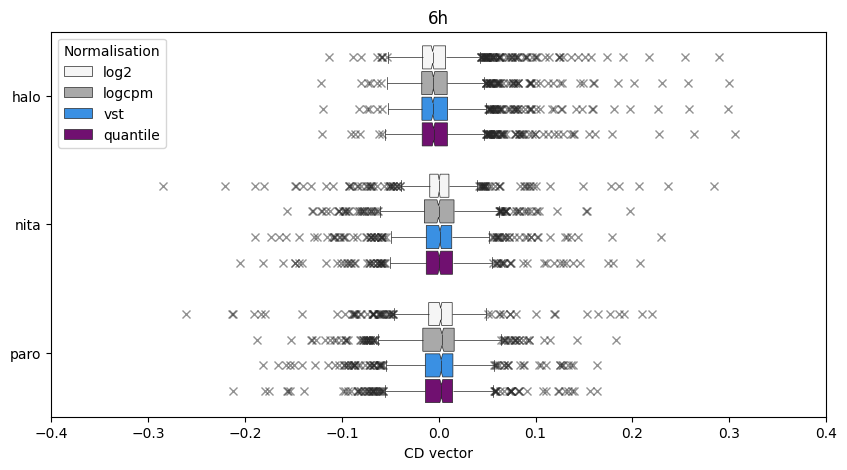

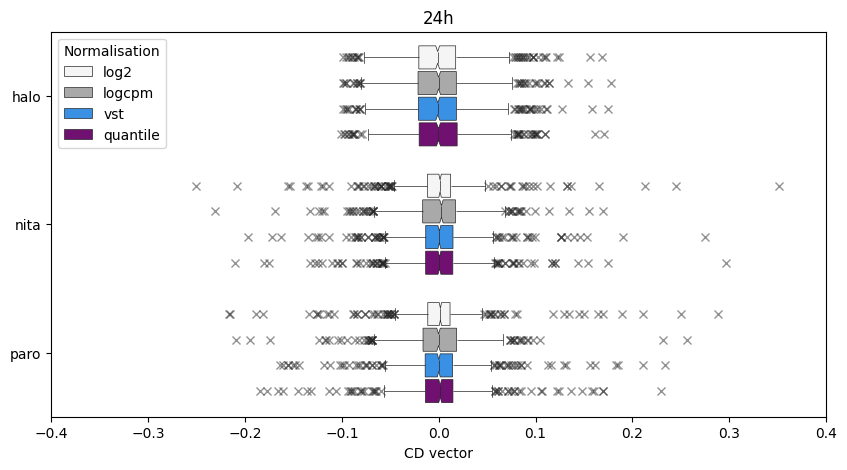

In [91]:
# Define palette
hue_palette = ['whitesmoke', 'darkgrey', 'dodgerblue', 'purple']
# Iterate through timepoints
for timepoint in list_timepoint:
    # Filter df_comparison
    df_plot = df_comparison[df_comparison['timepoint'] == timepoint]
    
    # Plot
    plt.figure(figsize = (10, 5))
    plt.title(f'{timepoint}')
    sns.boxplot(df_plot, x = 'cd', y = 'treatment', 
                hue = 'norm', hue_order = ['log2', 'logcpm', 'vst', 'quantile'], palette = hue_palette,
                gap = 0.1,
                linewidth = 0.5,
                notch = True,
                flierprops = {'marker' : 'x', 'alpha' : 0.5})
    plt.legend(title = 'Normalisation', loc = 'upper left')
    plt.xlim(-0.4, 0.4)
    plt.xlabel('CD vector')
    plt.ylabel('')
    plt.show()

## 3.2 Heatmaps

This section looks at the exact CD vector values derived from each normalisation method, for each gene in a treatment group, and across timepoints

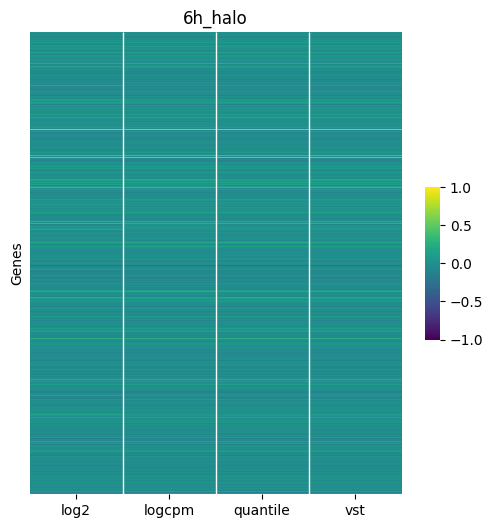

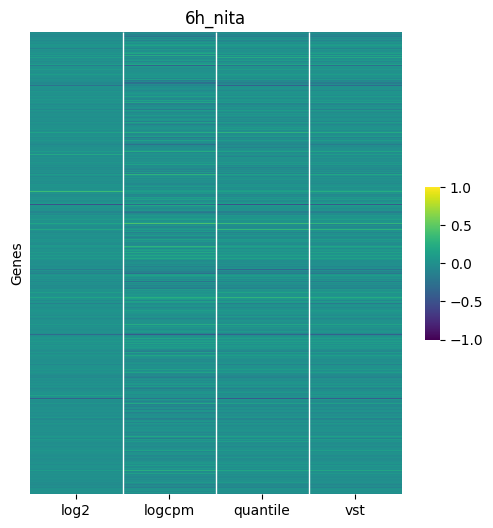

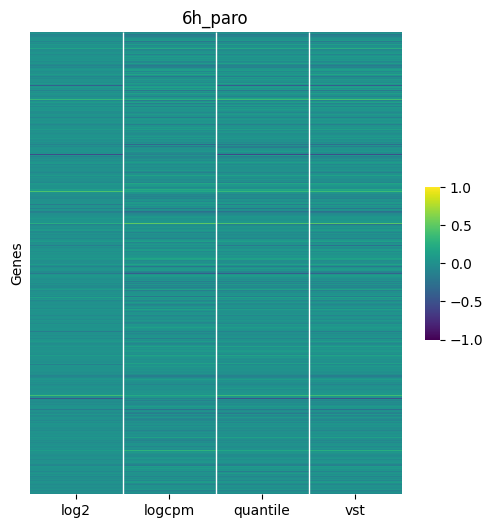

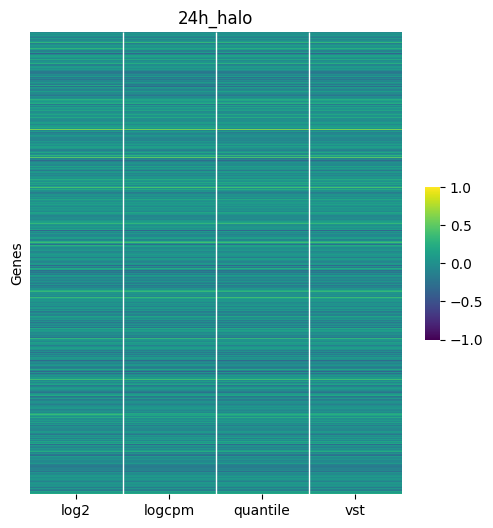

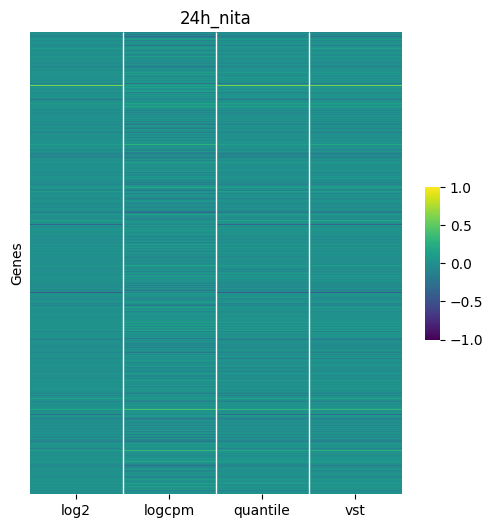

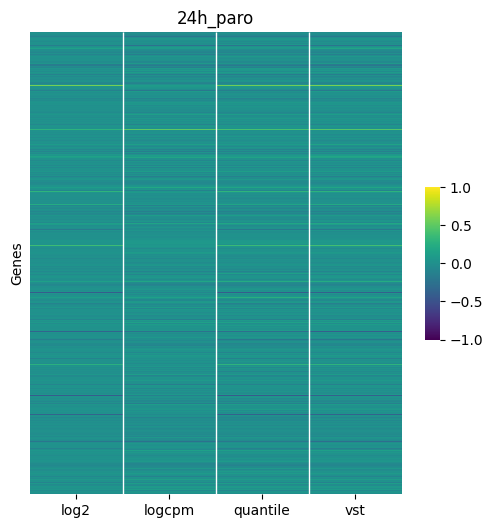

In [140]:
# Iterate through timepoints
for timepoint in list_timepoint:
    
    # Filter by treatment
    for treatment in list_treatment:

        # Filter df_comparison
        df = df_comparison[(df_comparison['timepoint'] == timepoint) &
                           (df_comparison['treatment'] == treatment)]
        # Pivot data
        df_hm = pd.pivot(df, index = 'gene_symbol', columns = 'norm', values = 'cd')
        # -1 to 1 normalise data
        df_scaled = (df_hm - df_hm.mean()) / (df_hm.max() - df_hm.min())

        # Plot
        plt.figure(figsize = (6, 6))
        plt.title(f'{timepoint}_{treatment}')
        hm = sns.heatmap(df_scaled, clip_on = False, linewidths = 0, linecolor = 'whitesmoke', 
                         cmap = 'viridis', vmin = -1, vmax = 1, 
                         yticklabels = False,
                         cbar_kws = {'shrink' : 0.33, 'aspect' : 10, 'pad' : 0.05})
        
        # Draw vertical lines between columns
        for x in range(1, df_scaled.shape[1]):
            hm.vlines(x, *hm.get_ylim(), colors='white', linewidth=1)
        
        # Format
        plt.ylabel('Genes')
        plt.xlabel('')
        plt.show()

# 4. PyG Graph List

This section takes quantile-derived CD vector data, and generates $n$ random graphs from CDS2 data

In [154]:
# Load graph
graph_cds = pickle_load(INPUT + 'graph_cds.pkl')
# Load quantile CD vector data
df_cd = pd.read_csv(CDV + 'cd_quantile_landmark.csv')
# Set index
df_cd.set_index('gene_symbol', inplace = True)

# Load parquet file
pf = pq.ParquetFile(INPUT + 'df_attr.parquet')
# Load document list
list_documents = pf.schema.names
# Report
print(f'{len(list_documents):,} signatures in CDS data')

119,156 signatures in CDS data


In [155]:
df_cd.head()

,24h_colo_halo,24h_colo_nita,24h_colo_paro,6h_colo_halo,6h_colo_nita,6h_colo_paro
gene_symbol,,,,,,
DUSP3,-0.006657,0.008870,0.015775,-0.023929,-0.011824,0.008770
TMED10,-0.044503,0.003056,0.008631,-0.019001,0.022450,0.018116
BLVRA,0.000689,-0.027416,0.009088,-0.008665,0.011156,0.059595
FAS,0.023943,-0.058019,-0.056247,-0.019231,0.015436,-0.034114
ERBB2,-0.036041,-0.030046,-0.022052,-0.009973,-0.003635,-0.011799


In [245]:
# Define filters
CELL_LINES = ['HT29']
TIMEPOINTS = ['6H']

# Filter list_documents
list_signatures = [entry for entry in list_documents if
                   any(cell_line in entry for cell_line in CELL_LINES) and
                   any(timepoint in entry for timepoint in TIMEPOINTS)]
# Report
print(f'{len(list_signatures):,} signatures found for {CELL_LINES} cell lines and {TIMEPOINTS} timepoints')

# Get statins
list_statins = [entry for entry in list_documents if 
                'statin' in entry and 
                'poscon' not in entry and
                any(cell_line in entry for cell_line in CELL_LINES) and 
                any(timepoint in entry for timepoint in TIMEPOINTS)]
# Report
print(f'{len(list_statins):,} signatures found for statins in {CELL_LINES} cell line and {TIMEPOINTS} timepoints')

6,079 signatures found for ['HT29'] cell lines and ['6H'] timepoints
16 signatures found for statins in ['HT29'] cell line and ['6H'] timepoints


In [247]:
# Define number of random signatures
NUM_ENTRIES = 100
# Sample signatures
list_random = random.sample(list_signatures, NUM_ENTRIES)
# Append statins
list_random = list_random + list_statins

In [248]:
# Define timepoint columns
list_columns = [column for column in df_cd.columns if '6h' in column]

# Initialise graph list
list_pyg = []

# Iterate through df_cd timepoint columns
for column in tqdm(list_columns, desc = 'Converting experimental data to PyG object(s)', total = len(list_columns)):

    # Get treatment name
    treatment_name = column.split('_')[2]
    # Get timepoint
    timepoint = column.split('_')[0].upper()

    # Extract column data as dictionary
    dict_column = df_cd[column].to_dict()
    
    # Copy graph_cds
    graph_column = graph_cds.copy()
    # Set node attributes
    nx.set_node_attributes(graph_column, dict_column, name = 'x')
    
    # Convert to PyG object
    pyg = from_networkx(graph_column)
    # Format 'x' attribute
    pyg.x = pyg.x.float()
    # Add treatment name
    pyg.name = f'{treatment_name}'
    # Add perturbagen timepoint
    pyg.timepoint = f'{timepoint}'
    # Append to graph list
    list_pyg.append(pyg)

# Iterate through list_random
for entry in tqdm(list_random, desc = 'Converting CDS data to PyG object(s)', total = len(list_random)):

    # Get signature ID
    signature_id = entry.split(':')[0]
    # Get cell line
    cell_line = signature_id.split('_')[1]
    # Get timepoint
    timepoint = signature_id.split('_')[2]
    # Get dose
    dose = entry.split(':')[2]

    # Get perturbagen name
    perturbagen_name = entry.split(':')[3]
    if '-666' in perturbagen_name:
        perturbagen_name = entry.split(':')[1]

    # Load signature from parquet file as dictionary
    dict_signature = pd.read_parquet(INPUT + 'df_attr.parquet', columns = [entry]).to_dict()
    dict_signature = dict_signature[entry]

    # Copy graph_cds
    graph_signature = graph_cds.copy()
    # Set node attributes
    nx.set_node_attributes(graph_signature, dict_signature, name = 'x')

    # Convert to PyG object
    pyg = from_networkx(graph_signature)
    # Format 'x' attribute
    pyg.x = pyg.x.float()
    # Add perturbagen anme
    pyg.name = f'{perturbagen_name}'
    # Add timepoint
    pyg.timepoint = f'{timepoint}'
    # Add dose
    pyg.dose = f'{dose}'
    # Add cell line
    pyg.cell = f'{cell_line}'
    # Append to graph list
    list_pyg.append(pyg)

Converting CDS data to PyG object(s): 100%|██████████| 116/116 [15:21<00:00,  7.94s/it]


# 5. GIN (Message Passing)

This section uses a message-passing only GIN to generate graph embeddings, and :
- Tests cosine similarity between perturbagens and a chosen treatment
- Observes how different the top $m$ closest perturbagens are with repeated testing
- Tests to see whether there is a cutoff for new unique perturbagens to appear in the top $m$ closest graphs

In [169]:
# Parameters
EMBED_DIM = 64

# Define GIN encoder using identity GINConvs and fixed projection to d dimensions
class GINEncoder(Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        
        # Project scalar node feature to d-dim before aggregation
        self.initial_proj = Linear(1, embed_dim)  # assuming input is 1-d per node

        # Identity "MLPs" in GINConv — only aggregate neighbors
        mlp1 = Sequential(Identity())
        mlp2 = Sequential(Identity())

        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)

        self.lin = Identity()  # optionally project again later

    def forward(self, x, edge_index):
        if x.dim() == 1:
            x = x.view(-1, 1)  # reshape from [901] → [901, 1]
        x = self.initial_proj(x)  # shape: [n, d]
        x = self.conv1(x, edge_index)
        x = F.relu(x)  # optional
        x = self.conv2(x, edge_index)
        return self.lin(x)  # shape: [n, d] — node-level embeddings

print('Identity-mapping GIN encoder complete')

# Function to generate embeddings given a random seed
def generate_embeddings(seed):
    torch.manual_seed(seed)
    encoder = GINEncoder()
    encoder.eval()
    graph_embeddings = []

    with torch.no_grad():
        for graph in list_pyg:
            x = encoder(graph.x, graph.edge_index)
            batch = torch.zeros(x.size(0), dtype=torch.long)
            graph_emb = global_add_pool(x, batch)
            graph_embeddings.append(graph_emb)
    
    matrix = torch.cat(graph_embeddings, dim=0).numpy()
    return matrix

print('generate_embeddings function defined')

Identity-mapping GIN encoder complete
generate_embeddings function defined


In [185]:
# Define target graph
TARGET_ID = 'halo'
# Define target timepoint
TARGET_TIMEPOINT = '6H'
# Define top n graphs for similarity
TOP_N = 10

# Define seed number list
list_seed_number = [5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 7500, 10000]

# Initialise results
df_results = pd.DataFrame()

# Iterate through seed number
for seed_number in list_seed_number:

    # Generate random integer seeds
    list_seeds = random.sample(range(1, 100000), seed_number)

    # Initialise results list
    seed_number_results = []

    # Iterate through seeds
    for seed in tqdm(list_seeds, desc = f'Generating embeddings for {seed_number} seeds', total = len(list_seeds)):

        # Generate embeddings
        matrix = generate_embeddings(seed)
        # Center embeddings
        centered = matrix - matrix.mean(axis = 0, keepdims = True)
        # Normalise embeddings
        centered_normalised = centered / np.linalg.norm(centered, axis = 1, keepdims = True)

        # Find reference graph index
        ref_idx = next(i for i, g in enumerate(list_pyg) if
                       g.name == TARGET_ID and 
                       g.timepoint == TARGET_TIMEPOINT)

        # Calculate cosine similarity of all graphs to reference graph
        sims = cosine_similarity([centered_normalised[ref_idx]], centered_normalised)[0]
        # Sort by similarity
        sims_sorted = sims.argsort()[::-1]

        # Get top N most similar graph names
        top_names = [list_pyg[graph].name for graph in sims_sorted[1:TOP_N+1]]
        # Get top N most similar graph scores
        top_scores = sims[sims_sorted[:TOP_N]]

        # Convert to dataframe
        df = pd.DataFrame({'seed' : seed,
                           'rank' : np.arange(1, TOP_N + 1),
                           'perturbagen_name' : top_names,
                           'cosine_similarity' : top_scores})
        
        # Append data
        seed_number_results.append(df)
        
    # Convert to dataframe
    df_seed_number_results = pd.concat(seed_number_results, ignore_index = True)   
    # Add column
    df_seed_number_results['run'] = str(seed_number)
    # Concatenate
    df_results = pd.concat([df_results, df_seed_number_results])

# Show data
df_results.head(10)

Generating embeddings for 10000 seeds: 100%|██████████| 10000/10000 [19:33<00:00,  8.52it/s]


,seed,rank,perturbagen_name,cosine_similarity,run
0,15084,1,BG FA 0953,1.000000,5
1,15084,2,BRD-K86899078,0.999799,5
2,15084,3,GR 113808,0.999793,5
3,15084,4,BRD-K85818861,0.999792,5
4,15084,5,BRD-K65904652,0.999792,5
5,15084,6,TL_HRAS27 BRD-K15166186,0.999791,5
6,15084,7,DM163 BRD-K06180729,0.999791,5
7,15084,8,SPB02137,0.999791,5
8,15084,9,cefdinir,0.999791,5
9,15084,10,BRD-K76840893,0.999791,5


<Axes: xlabel='seed_num', ylabel='unique_perturbagens'>

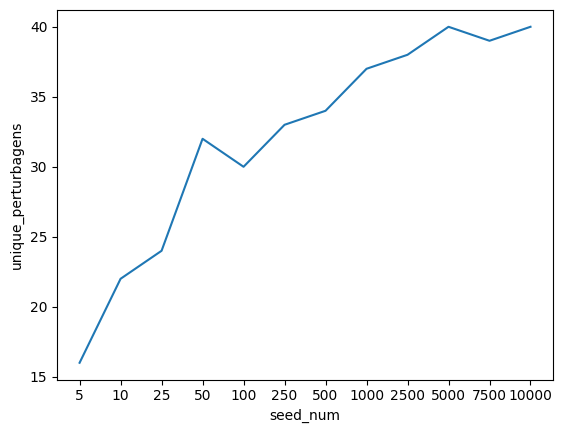

In [186]:
# Initialise dataframe
list_plot = []

# Iterate through runs
for run in pd.unique(df_results['run']):
    # Slice dataframe
    df_slice = df_results[df_results['run'] == run]
    # Get unique perturbagen names
    list_unique_perturbagens = pd.unique(df_slice['perturbagen_name'])
    # Get number of unique perturbagen names
    num_unique_perturbagens = len(list_unique_perturbagens)
    # Append data
    list_plot.append((run, num_unique_perturbagens))

# Convert to dataframe
df_plot = pd.DataFrame(list_plot, columns = ['seed_num', 'unique_perturbagens'])
# Plot
sns.lineplot(df_plot, x = 'seed_num', y = 'unique_perturbagens')

In [ ]:
df_grouped = df_results.groupby('perturbagen_name')['rank'].mean().sort_values()
df_grouped

# 6. GIN (learning)

In [ ]:
# =========================
# Imports
# =========================
import torch
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.data import Data, DataLoader, Batch
from tqdm import tqdm
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity

# =========================
# 0. Preprocess graphs
# =========================

def preprocess_graphs(list_pyg):
    keys_to_keep = ['x', 'edge_index', 'num_nodes', 'name', 'timepoint']
    for g in list_pyg:
        # Remove unnecessary attributes
        for key in list(g.keys()):  # <-- call keys() as a method
            if key not in keys_to_keep:
                del g[key]

        # Make x 2D
        if g.x.dim() == 1:
            g.x = g.x.view(-1, 1)
    return list_pyg

# =========================
# 1. Define the GIN encoder
# =========================
class GINEncoder(torch.nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim
            mlp = Sequential(Linear(in_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
            conv = GINConv(mlp)
            self.convs.append(conv)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
        graph_emb = global_add_pool(x, batch)  # graph-level embedding
        return graph_emb

# =========================
# 2. Contrastive loss
# =========================
# def info_nce_loss(z1, z2, temperature=0.5):
#     z1 = F.normalize(z1, dim=1)
#     z2 = F.normalize(z2, dim=1)
#     batch_size = z1.size(0)
#     representations = torch.cat([z1, z2], dim=0)
#     similarity_matrix = torch.matmul(representations, representations.T)
#     mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z1.device)
#     similarity_matrix = similarity_matrix.masked_fill(mask, float('-inf'))

#     labels = torch.arange(batch_size, device=z1.device)
#     # Positive pairs are on the diagonal offset
#     positives = torch.sum(z1 * z2, dim=-1) / temperature

#     # Use similarity matrix rows for cross-entropy
#     loss1 = F.cross_entropy(similarity_matrix[:batch_size], labels)
#     loss2 = F.cross_entropy(similarity_matrix[batch_size:], labels)
#     return (loss1 + loss2) / 2

def info_nce_loss(z1, z2, temperature=0.5):
    # Normalize embeddings
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    
    batch_size = z1.size(0)
    
    # Cosine similarity matrix
    representations = torch.cat([z1, z2], dim=0)  # [2*B, D]
    sim_matrix = torch.matmul(representations, representations.T)  # [2B,2B]
    
    # Scale by temperature
    sim_matrix = sim_matrix / temperature
    
    # Labels: each sample i in z1 matches i+B in z2, and vice versa
    labels = torch.arange(batch_size, device=z1.device)
    
    # Mask out self-similarities
    mask = torch.eye(2*batch_size, device=z1.device).bool()
    sim_matrix.masked_fill_(mask, -9e15)  # very large negative number instead of -inf
    
    # Positive logits
    positives = torch.cat([torch.arange(batch_size, batch_size*2), torch.arange(0, batch_size)]).to(z1.device)
    
    # Cross-entropy
    loss = F.cross_entropy(sim_matrix, positives)
    return loss

# =========================
# 3. Graph augmentation
# =========================
def augment_graph_batch(batch_graphs, noise_scale=0.1):
    x_aug = batch_graphs.x + noise_scale * torch.randn_like(batch_graphs.x)
    batch_aug = Batch(batch_graphs.to_data_list())
    batch_aug.x = x_aug.to(batch_graphs.x.device)
    batch_aug.edge_index = batch_graphs.edge_index
    batch_aug.batch = batch_graphs.batch
    return batch_aug

# =========================
# 4. Preprocess graphs: remove inconsistent attributes
# =========================
def strip_graph_attributes(list_pyg):
    keys_to_keep = ['x', 'edge_index', 'num_nodes', 'name', 'timepoint']
    for g in list_pyg:
        for k in list(g.__dict__.keys()):
            if k not in keys_to_keep and not k.startswith('_'):
                del g[k]
    return list_pyg

# =========================
# 5. Training loop
# =========================
def train_contrastive_gin(list_pyg, embed_dim=64, epochs=30, batch_size=4, lr=1e-3, device=None):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

    list_pyg = strip_graph_attributes(list_pyg)
    loader = DataLoader(list_pyg, batch_size=batch_size, shuffle=True)
    encoder = GINEncoder(input_dim=1, hidden_dim=embed_dim).to(device)
    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)

    #for epoch in tqdm(range(epochs), desc = f'Training contrastive GIN', total = epochs):
    for epoch in range(epochs):
        encoder.train()
        total_loss = 0
        #for batch_graphs in tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}'):
        for batch_graphs in loader:
            batch_graphs = batch_graphs.to(device)
            batch_aug = augment_graph_batch(batch_graphs)

            z1 = encoder(batch_graphs.x, batch_graphs.edge_index, batch_graphs.batch)
            z2 = encoder(batch_aug.x, batch_aug.edge_index, batch_aug.batch)

            loss = info_nce_loss(z1, z2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        # Report loss per epoch
        #print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

    return encoder

# =========================
# 6. Generate embeddings and keep mapping
# =========================
def get_graph_embeddings(encoder, list_pyg, device=None):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    encoder.eval()
    embeddings = []
    graph_info = []
    with torch.no_grad():
        for g in tqdm(list_pyg, desc="Generating embeddings"):
            g = g.to(device)
            batch = torch.zeros(g.num_nodes, dtype=torch.long, device=device)
            z = encoder(g.x, g.edge_index, batch)
            embeddings.append(z.cpu())
            graph_info.append({'name': g.name, 'timepoint': g.timepoint})
    embeddings = torch.cat(embeddings, dim=0).numpy()
    return embeddings, graph_info

# =========================
# 7. Example usage
# =========================
list_pyg = preprocess_graphs(list_pyg)

encoder = train_contrastive_gin(list_pyg, embed_dim=64, epochs=150, batch_size=32)
embeddings, graph_info = get_graph_embeddings(encoder, list_pyg)

# Center embeddings
emb_centered = embeddings - embeddings.mean(axis=0, keepdims=True)
# Normalize each vector
emb_norm = emb_centered / np.linalg.norm(emb_centered, axis=1, keepdims=True)

In [282]:
sim_matrix = cosine_similarity(emb_norm)
#sim_matrix = cosine_similarity(embeddings)
# Define reference treatment
REF_TREATMENT = 'halo'

# Get top N closest results to reference graph
ref_idx = next(i for i, g in enumerate(graph_info) if g['name'] == REF_TREATMENT and g['timepoint']=='6H')
results = np.argsort(sim_matrix[ref_idx])[::-1]
df_results = pd.DataFrame([(graph_info[i]['name'], graph_info[i]['timepoint'], sim_matrix[ref_idx, i]) for i in results], columns = ['name', 'timepoint', 'cosim'])
df_results.iloc[1:11,:]

,name,timepoint,cosim
1,NCGC00241435-01,6H,0.560969
2,BRD-K84987553,6H,0.557117
3,NCGC00182390-01,6H,0.516472
4,Dephostatin,6H,0.499998
5,BRD-K96076993,6H,0.437818
6,T5212475,6H,0.429699
7,BRD-K89997465,6H,0.429036
8,MLS-0435557.0001,6H,0.423277
9,Pepstatin A,6H,0.422080
10,PAROXETINE HYDROCHLORIDE,6H,0.418681


In [276]:
# uMAP
reducer = umap.UMAP(n_components=2, random_state=42, spread = 1)
embedding_2d = reducer.fit_transform(emb_norm)
graph_ids = [g.name for g in list_pyg]
graph_timepoints = [g.timepoint for g in list_pyg]

# Convert to dataframe
df_plot = pd.DataFrame(embedding_2d, columns = ['x', 'y'])
df_plot['perturbagen_name'] = graph_ids
df_plot['timepoint'] = graph_timepoints

# Filter data
# df_plot = df_plot[(df_plot['timepoint'] == '6H') |
#                   (df_plot['timepoint'] == '24H')]
df_plot = df_plot[df_plot['timepoint'] == '6H']

# Show data
df_plot.head()

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,x,y,perturbagen_name,timepoint
0,7.784876,16.991066,halo,6H
1,7.766575,17.051964,nita,6H
2,7.816369,17.226385,paro,6H
3,8.908039,-1.774827,BRD-A34907681,6H
4,10.967182,13.438969,BRD-K30849099,6H


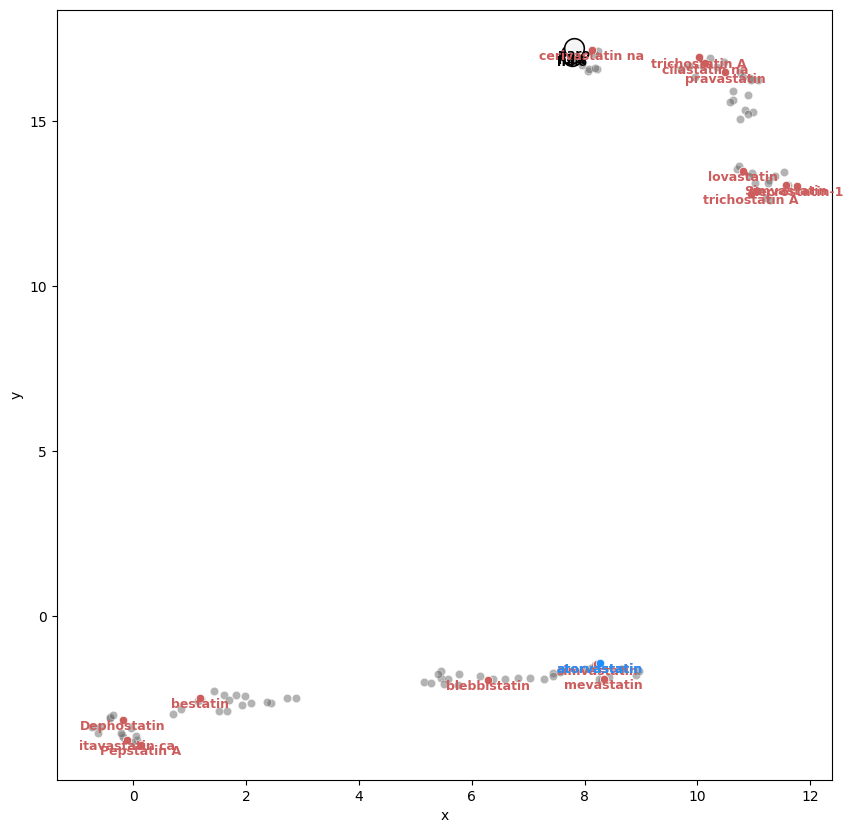

In [277]:
list_known_ids = ['halo', 'nita', 'paro']

subset = df_plot[df_plot['perturbagen_name'].isin(list_known_ids)]
statins = df_plot[df_plot['perturbagen_name'].str.contains('statin')]
ator = df_plot[df_plot['perturbagen_name'].str.contains('atorvastatin')]

plt.figure(figsize = (10,10))
sns.scatterplot(df_plot, x = 'x', y = 'y', c = 'dimgrey', alpha = 0.5)
sns.scatterplot(statins, x = 'x', y = 'y', c = 'indianred')
sns.scatterplot(ator, x = 'x', y = 'y', c = 'dodgerblue')
sns.scatterplot(subset, x = 'x', y = 'y', s = 200, c = 'whitesmoke', edgecolor = 'black', legend = None, label = 'perturbagen_name')
# Add text labels for each highlighted point
for _, row in subset.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='black'
    )

# Add text labels for each highlighted point
for _, row in statins.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='indianred'
    )

# Add text labels for each highlighted point
for _, row in ator.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='dodgerblue'
    )

## Multiple runs

In [321]:
from scipy.stats import spearmanr

# Define multi-run parameters
num_runs = 25
sim_matrices = []
graph_info_list = []
# Define reference treatment
REF_TREATMENT = 'halo'

for seed in tqdm(range(num_runs), desc = 'Multiple GIN runs', total = num_runs):
    torch.manual_seed(seed)
    np.random.seed(seed)

    encoder = train_contrastive_gin(list_pyg, embed_dim=64, epochs=150, batch_size=32)
    embeddings, graph_info = get_graph_embeddings(encoder, list_pyg)

    # Center and normalize
    emb_centered = embeddings - embeddings.mean(axis=0, keepdims=True)
    emb_norm = emb_centered / np.linalg.norm(emb_centered, axis=1, keepdims=True)

    sim_matrices.append(cosine_similarity(emb_norm))
    graph_info_list = graph_info  # same across runs

# Reference graph index (e.g., "halo 6H")
ref_idx = next(i for i, g in enumerate(graph_info_list) if REF_TREATMENT in g['name'])

# # Flatten upper triangle to avoid redundant symmetry
# def upper_tri(mat):
#     idx = np.triu_indices_from(mat, k=1)
#     return mat[idx]

# for i in range(num_runs):
#     for j in range(i+1, num_runs):
#         corr = np.corrcoef(upper_tri(sim_matrices[i]), upper_tri(sim_matrices[j]))[0,1]
#         print(f"Run {i} vs {j}: correlation = {corr:.3f}")

# ==========================
# 2. Compute pairwise correlations
# ==========================
def upper_tri(mat):
    idx = np.triu_indices_from(mat, k=1)
    return mat[idx]

corr_matrix = np.zeros((num_runs, num_runs))
spearman_matrix = np.zeros((num_runs, num_runs))

for i in range(num_runs):
    for j in range(i+1, num_runs):
        # Pearson correlation of upper triangles
        corr = np.corrcoef(upper_tri(sim_matrices[i]), upper_tri(sim_matrices[j]))[0, 1]
        corr_matrix[i, j] = corr_matrix[j, i] = corr

        # Spearman rank correlation for reference graph similarities
        rho, _ = spearmanr(sim_matrices[i][ref_idx], sim_matrices[j][ref_idx])
        spearman_matrix[i, j] = spearman_matrix[j, i] = rho

# ==========================
# 3. Compute consistency per run
# ==========================
mean_corr = corr_matrix.mean(axis=1)
mean_spearman = spearman_matrix.mean(axis=1)

consistency_df = pd.DataFrame({
    'run': range(num_runs),
    'mean_corr': mean_corr,
    'mean_spearman': mean_spearman,
    'combined_score': mean_corr + mean_spearman
}).sort_values('combined_score', ascending=False)

# best_run = int(consistency_df.iloc[0]['run'])
# print("\n=== Consistency Results ===")
# print(consistency_df.round(3))
# print(f"\nMost stable run: {best_run} (combined score = {consistency_df.iloc[0]['combined_score']:.3f})")

# # ==========================
# # 4. Consensus ranking
# # ==========================
# # Get ranked list of most similar graphs to ref_idx for each run
# all_rankings = [np.argsort(-sim[ref_idx]) for sim in sim_matrices]

# # Aggregate ranks across runs (Borda average)
# ranks = np.zeros((num_runs, len(all_rankings[0])))
# for r, ranking in enumerate(all_rankings):
#     for rank_pos, g_idx in enumerate(ranking):
#         ranks[r, g_idx] = rank_pos
# avg_rank = ranks.mean(axis=0)
# consensus_order = np.argsort(avg_rank)

# # ==========================
# # 5. Display top-10 consensus
# # ==========================
# top_k = 10
# top_graphs = [
#     graph_info_list[i]['name'] for i in consensus_order[:top_k]
# ]

# print("\n=== Consensus Top-10 Most Similar to Reference ===")
# for rank, name in enumerate(top_graphs, 1):
#     print(f"{rank}. {name}")

# Compute top-k overlap Jaccard between runs
k = 10
jaccard_matrix = np.zeros((num_runs, num_runs))

for i, j in combinations(range(num_runs), 2):
    top_i = set(np.argsort(-sim_matrices[i][ref_idx])[:k])
    top_j = set(np.argsort(-sim_matrices[j][ref_idx])[:k])
    jacc = jaccard_similarity(top_i, top_j)
    jaccard_matrix[i, j] = jaccard_matrix[j, i] = jacc

# Mean Jaccard per run
mean_jaccard = jaccard_matrix.mean(axis=1)
consistency_df['mean_jaccard'] = mean_jaccard
consistency_df['combined_score'] = (
    0.5 * (consistency_df['mean_corr'] + consistency_df['mean_spearman']) +
    0.5 * consistency_df['mean_jaccard']
)
consistency_df = consistency_df.sort_values('combined_score', ascending=False)

# print("\n=== Updated Consistency with Jaccard ===")
# print(consistency_df.round(3))

consistency_df.head()

Multiple GIN runs:   0%|          | 0/25 [00:00<?, ?it/s]c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
Multiple GIN runs:   4%|▍         | 1/25 [00:14<05:37, 14.04s/it]c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
Multiple GIN runs:   8%|▊         | 2/25 [00:27<05:20, 13.92s/it]c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
Multiple GIN runs:  12%|█▏        | 3/25 [00:41<05:06, 13.93s/it]c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.

,run,mean_corr,mean_spearman,combined_score,mean_jaccard
16,16,0.911100,0.829225,1.148637,0.556950
14,14,0.920946,0.837675,1.140385,0.522150
0,0,0.871216,0.850045,1.139105,0.556950
6,6,0.892443,0.836341,1.138453,0.548122
22,22,0.901150,0.832123,1.125817,0.518362


In [327]:
q1 = np.quantile(consistency_df['combined_score'], 0.25)
q3 = np.quantile(consistency_df['combined_score'], 0.75)
iqr = q3 - q1
upper_threshold = q3 + (1.5 * iqr)

consistency_df[consistency_df['combined_score'] >= upper_threshold]

,run,mean_corr,mean_spearman,combined_score,mean_jaccard


In [328]:
consistency_df.head(10)

,run,mean_corr,mean_spearman,combined_score,mean_jaccard
16,16,0.911100,0.829225,1.148637,0.556950
14,14,0.920946,0.837675,1.140385,0.522150
0,0,0.871216,0.850045,1.139105,0.556950
6,6,0.892443,0.836341,1.138453,0.548122
22,22,0.901150,0.832123,1.125817,0.518362
10,10,0.907340,0.815095,1.125765,0.529094
3,3,0.883201,0.812435,1.121879,0.548122
23,23,0.911679,0.822202,1.118945,0.504009
17,17,0.918841,0.806167,1.096750,0.468492
13,13,0.874422,0.837820,1.093655,0.475069


In [346]:
pickle_save(OUTPUT + 'list_pyg.pkl', list_pyg)

In [291]:
# from itertools import combinations

# def jaccard_similarity(set1, set2):
#     return len(set1 & set2) / len(set1 | set2)

# # Compute top-k overlap Jaccard between runs
# k = 10
# jaccard_matrix = np.zeros((num_runs, num_runs))

# for i, j in combinations(range(num_runs), 2):
#     top_i = set(np.argsort(-sim_matrices[i][ref_idx])[:k])
#     top_j = set(np.argsort(-sim_matrices[j][ref_idx])[:k])
#     jacc = jaccard_similarity(top_i, top_j)
#     jaccard_matrix[i, j] = jaccard_matrix[j, i] = jacc

# # Mean Jaccard per run
# mean_jaccard = jaccard_matrix.mean(axis=1)
# consistency_df['mean_jaccard'] = mean_jaccard
# consistency_df['combined_score'] = (
#     0.5 * (consistency_df['mean_corr'] + consistency_df['mean_spearman']) +
#     0.5 * consistency_df['mean_jaccard']
# )
# consistency_df = consistency_df.sort_values('combined_score', ascending=False)

# print("\n=== Updated Consistency with Jaccard ===")
# print(consistency_df.round(3))


=== Updated Consistency with Jaccard ===
   run  mean_corr  mean_spearman  combined_score  mean_jaccard
1    1      0.765          0.458           0.791         0.359
4    4      0.776          0.456           0.774         0.315
3    3      0.758          0.411           0.768         0.368
2    2      0.781          0.462           0.642         0.042
0    0      0.753         -0.433           0.344         0.368


In [331]:
# =========================
# 1. Select top runs based on consistency
# =========================
top_runs_idx = [16, 0, 6, 3, 10]  # based on combined consistency metrics
#top_runs_idx = [16, 4]
embeddings_list = [sim_matrices[i] for i in top_runs_idx]  # list of sim matrices or embeddings

# If you have raw embeddings per run:
# embeddings_list = [embeddings_run0, embeddings_run1, embeddings_run2, ...] 
# make sure same order of graphs in each

# =========================
# 2. Compute consensus embedding
# =========================
# Stack embeddings: shape = (num_runs, num_graphs, embed_dim)
stacked_embs = np.stack([embeddings_per_run for embeddings_per_run in embeddings_list], axis=0)
consensus_emb = np.mean(stacked_embs, axis=0)  # average across runs

# Center and normalize
consensus_emb -= consensus_emb.mean(axis=0, keepdims=True)
consensus_emb /= np.linalg.norm(consensus_emb, axis=1, keepdims=True)

# =========================
# 3. Cosine similarity
# =========================
sim_matrix = cosine_similarity(consensus_emb)

# =========================
# 4. Find top-k closest graphs to "halo"
# =========================
REF_TREATMENT = 'halo'

halo_idx = next(i for i, g in enumerate(graph_info_list) if g['name']==REF_TREATMENT and g['timepoint']=='6H')
top_idx = np.argsort(sim_matrix[halo_idx])[::-1][1:11]  # exclude self

# Build DataFrame
df_consensus = pd.DataFrame([
    (graph_info_list[i]['name'], graph_info_list[i]['timepoint'], sim_matrix[halo_idx, i])
    for i in top_idx
], columns=['name','timepoint','cosim'])

df_consensus.head(10)

,name,timepoint,cosim
0,NCGC00241435-01,6H,0.994194
1,BRD-K84987553,6H,0.994138
2,NCGC00182390-01,6H,0.993436
3,Dephostatin,6H,0.993216
4,MLS-0435557.0001,6H,0.991541
5,Pepstatin A,6H,0.991464
6,BRD-K89997465,6H,0.991447
7,VU0414833-2,6H,0.991382
8,BRD-K33204703,6H,0.991139
9,itavastatin ca,6H,0.990950


In [332]:
# uMAP
reducer = umap.UMAP(n_components=2, random_state=42, spread = 1)
embedding_2d = reducer.fit_transform(consensus_emb)
graph_ids = [g.name for g in list_pyg]
graph_timepoints = [g.timepoint for g in list_pyg]

# Convert to dataframe
df_plot = pd.DataFrame(embedding_2d, columns = ['x', 'y'])
df_plot['perturbagen_name'] = graph_ids
df_plot['timepoint'] = graph_timepoints

# Filter data
# df_plot = df_plot[(df_plot['timepoint'] == '6H') |
#                   (df_plot['timepoint'] == '24H')]
df_plot = df_plot[df_plot['timepoint'] == '6H']

# Show data
df_plot.head()

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,x,y,perturbagen_name,timepoint
0,8.810287,3.117964,halo,6H
1,-0.048782,6.578426,nita,6H
2,-0.007766,6.628842,paro,6H
3,-8.232944,5.618651,BRD-A34907681,6H
4,-4.795401,5.161209,BRD-K30849099,6H


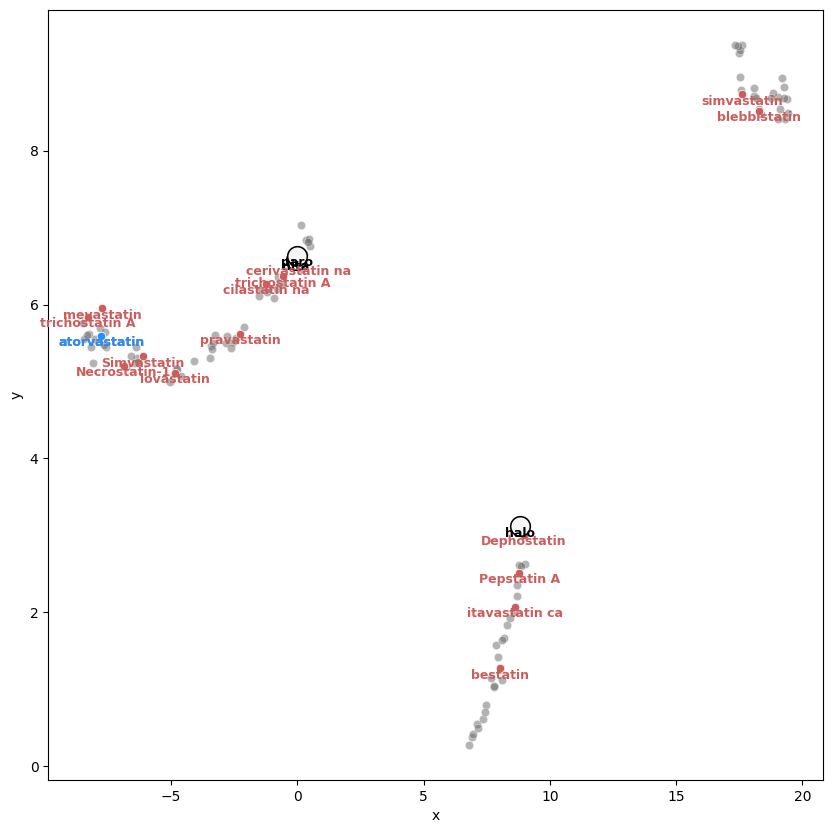

In [333]:
list_known_ids = ['halo', 'nita', 'paro']

subset = df_plot[df_plot['perturbagen_name'].isin(list_known_ids)]
statins = df_plot[df_plot['perturbagen_name'].str.contains('statin')]
ator = df_plot[df_plot['perturbagen_name'].str.contains('atorvastatin')]

plt.figure(figsize = (10,10))
sns.scatterplot(df_plot, x = 'x', y = 'y', c = 'dimgrey', alpha = 0.5)
sns.scatterplot(statins, x = 'x', y = 'y', c = 'indianred')
sns.scatterplot(ator, x = 'x', y = 'y', c = 'dodgerblue')
sns.scatterplot(subset, x = 'x', y = 'y', s = 200, c = 'whitesmoke', edgecolor = 'black', legend = None, label = 'perturbagen_name')
# Add text labels for each highlighted point
for _, row in subset.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='black'
    )

# Add text labels for each highlighted point
for _, row in statins.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='indianred'
    )

# Add text labels for each highlighted point
for _, row in ator.iterrows():
    plt.text(
        row['x'], row['y'], row['perturbagen_name'],
        fontsize=9, weight='bold',
        ha='center', va='top',  
        color='dodgerblue'
    )

In [334]:
# Define reference treatment
REF_TREATMENT = 'halo'

# Get top N closest results to reference graph
ref_idx = next(i for i, g in enumerate(graph_info) if g['name'] == REF_TREATMENT and g['timepoint']=='6H')
results = np.argsort(sim_matrix[ref_idx])[::-1]
df_results = pd.DataFrame([(graph_info[i]['name'], graph_info[i]['timepoint'], sim_matrix[ref_idx, i]) for i in results], columns = ['name', 'timepoint', 'cosim'])
df_results.iloc[1:11,:]

,name,timepoint,cosim
1,NCGC00241435-01,6H,0.994194
2,BRD-K84987553,6H,0.994138
3,NCGC00182390-01,6H,0.993436
4,Dephostatin,6H,0.993216
5,MLS-0435557.0001,6H,0.991541
6,Pepstatin A,6H,0.991464
7,BRD-K89997465,6H,0.991447
8,VU0414833-2,6H,0.991382
9,BRD-K33204703,6H,0.991139
10,itavastatin ca,6H,0.990950


## Clustering

In [343]:
import hdbscan
# Initialise clustering
#clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
clusterer = hdbscan.HDBSCAN()
# Get cluster labels
labels = clusterer.fit_predict(consensus_emb)

# Initialise dataframe
df_cluster = df_plot.copy()
df_cluster['cluster'] = labels

# Report number of clusters identified
num_clusters = len(pd.unique(df_cluster['cluster']))
print(f'{num_clusters} clusters identified')

# Show data
df_cluster.head()

4 clusters identified


c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,x,y,perturbagen_name,timepoint,cluster
0,8.810287,3.117964,halo,6H,0
1,-0.048782,6.578426,nita,6H,-1
2,-0.007766,6.628842,paro,6H,-1
3,-8.232944,5.618651,BRD-A34907681,6H,-1
4,-4.795401,5.161209,BRD-K30849099,6H,-1


In [344]:
# Initialise list
representatives = []

# Iterate through identified clusteres
for label, cluster in df_cluster.groupby('cluster'):
    # Check for labels > -1 (points designated as 'noise')
    if label > -1:
        # Get cluster centroid
        centroid = cluster[['x', 'y']].mean().values
        # Calculate distances of each drug in cluster to centroid
        distances = np.linalg.norm(cluster[['x', 'y']].values - centroid, axis=1)
        # Get closest drug
        closest_drug = cluster.index[np.argmin(distances)]
        # Append to list
        representatives.append(df_cluster.loc[closest_drug])
    
# Convert to dataframe
df_representatives = pd.DataFrame(representatives)
# Show data
df_representatives.head()

,x,y,perturbagen_name,timepoint,cluster
54,8.993292,3.116248,NCGC00182390-01,6H,0
14,-6.341362,5.301572,BIBX 1382 dihydrochloride,6H,1
25,-2.124018,5.706469,BRD-K85051645,6H,2


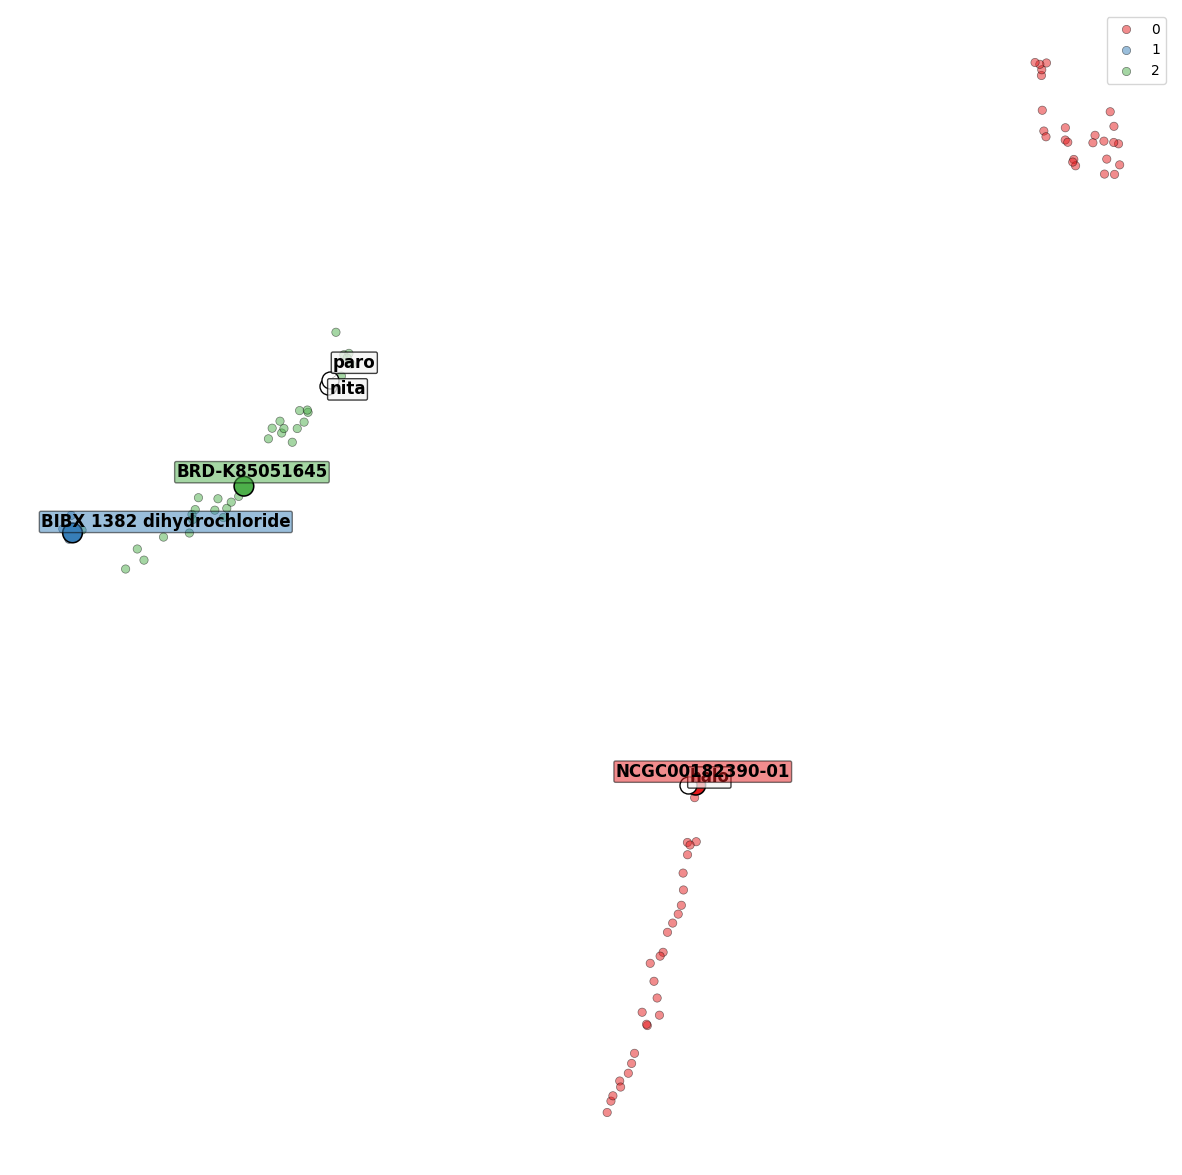

In [345]:
from adjustText import adjust_text

# Plot
plt.figure(figsize = (15,15))
plt.axis('off')

# Plot clusters
sns.scatterplot(df_cluster[df_cluster['cluster'] != -1], 
                x = 'x', y = 'y', 
                hue = 'cluster', palette = 'Set1', 
                alpha = 0.5, edgecolors = 'black')
# Plot representative points
sns.scatterplot(df_representatives, 
                x = 'x', y = 'y', 
                hue = 'cluster', palette = 'Set1', 
                edgecolors = 'black', s = 200, legend = False)
# Plot known anti-malarials
sns.scatterplot(df_cluster[df_cluster['perturbagen_name'].isin(list_known_ids)], 
                x = 'x', y = 'y', 
                c = 'white', s = 150, alpha = 1, edgecolors = 'black')

# Set label styling
malarial_style = {'fontsize': 12,
                  'alpha' : 1,
                  'weight' : 'bold',
                  'color': 'black',
                  'bbox': {'facecolor': 'whitesmoke',
                           'alpha': 0.75,
                           'edgecolor': 'black',
                           'boxstyle': 'round,pad=0.1'}}

# Initialise text label list
texts = []

# Iterate through anti-malarial IDs
for id in list_known_ids:
    # Slice dataframe
    df_slice = df_cluster[df_cluster['perturbagen_name'] == id]
    # Get coordinates
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    # Get label
    label = df_slice['perturbagen_name'].values[0]
    # Append with styling
    texts.append(plt.text(x, y, label, **malarial_style));

# Adjust labels
adjust_text(texts,
            arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25),
            expand = (1,1));

# Initialise representative text label list
rep_texts = []

# Get first n colours from Set1 palette
n = 10
palette_colors = list(sns.color_palette('Set1', n_colors=n))

# Iterate through representative drug IDs and palette colours
for id, colour in zip(pd.unique(df_representatives['perturbagen_name']), palette_colors):
    # Slice dataframe
    df_slice = df_representatives[df_representatives['perturbagen_name'] == id]
    # Get coordinates
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    # Get label
    label = df_slice['perturbagen_name'].values[0]

    # Set label styling
    rep_style = {'fontsize': 12,
                 'alpha' : 1,
                 'weight' : 'bold',
                 'color': 'black',
                 'ha': 'center',             
                 'va': 'bottom',             
                 'bbox': {'facecolor': colour,
                          'alpha': 0.5,
                          'edgecolor': 'black',
                          'boxstyle': 'round,pad=0.1'}}

    # Append with styling
    rep_texts.append(plt.text(x, y, label, **rep_style))

# Adjust text labels
adjust_text(rep_texts,
            arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25));

# Show plot
plt.show()